In [1]:
import pandas as pd
import os
import traceback
import ast
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Define the folder containing your CSV files
folder_path = "data"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Read and concatenate them into a single DataFrame
df_list = [pd.read_csv(os.path.join(folder_path, file)) for file in csv_files]
merged_df = pd.concat(df_list, ignore_index=True)

# Preview merged data
print(merged_df.head())


  success          rt              trial_type  trial_index plugin_version  \
0    True  30974776.0              fullscreen            0            NaN   
1     NaN     71994.0           external-html            1          2.1.0   
2     NaN     47180.0    html-button-response            2          2.1.0   
3     NaN     46719.0                  survey            3          2.1.0   
4     NaN         NaN  html-keyboard-response            4          2.0.0   

   time_elapsed    random_id           url  \
0      30975816  pztcfa1tggb           NaN   
1      31047994  pztcfa1tggb  consent.html   
2      31095178  pztcfa1tggb           NaN   
3      31142023  pztcfa1tggb           NaN   
4      31145033  pztcfa1tggb           NaN   

                                            stimulus  \
0                                                NaN   
1                                                NaN   
2  \n                <h2>Welcome to our study!</h...   
3                                   

In [2]:
# Check number of rows and columns
print(merged_df.shape)  # Output: (num_rows, num_columns)

# Display the first 10 rows (instead of just 5)
print(merged_df.head(10))

# Display the last 10 rows
print(merged_df.tail(10))


(8451, 26)
  success          rt              trial_type  trial_index plugin_version  \
0    True  30974776.0              fullscreen            0            NaN   
1     NaN     71994.0           external-html            1          2.1.0   
2     NaN     47180.0    html-button-response            2          2.1.0   
3     NaN     46719.0                  survey            3          2.1.0   
4     NaN         NaN  html-keyboard-response            4          2.0.0   
5     NaN      9242.0    html-button-response            5          2.1.0   
6     NaN         NaN  html-keyboard-response            6          2.0.0   
7     NaN         NaN  html-keyboard-response            7          2.0.0   
8     NaN         NaN  html-keyboard-response            8          2.0.0   
9     NaN         NaN  html-keyboard-response            9          2.0.0   

   time_elapsed    random_id           url  \
0      30975816  pztcfa1tggb           NaN   
1      31047994  pztcfa1tggb  consent.html   
2  

In [3]:
print(merged_df.info())  # See if there are missing values or unusual data types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8451 entries, 0 to 8450
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   success            49 non-null     object 
 1   rt                 2481 non-null   float64
 2   trial_type         8451 non-null   object 
 3   trial_index        8451 non-null   int64  
 4   plugin_version     8402 non-null   object 
 5   time_elapsed       8451 non-null   int64  
 6   random_id          8451 non-null   object 
 7   url                49 non-null     object 
 8   stimulus           8064 non-null   object 
 9   response           2383 non-null   object 
 10  phase              7726 non-null   object 
 11  type               5730 non-null   object 
 12  word               2865 non-null   object 
 13  correct_choice     925 non-null    float64
 14  problem            880 non-null    object 
 15  correct            1820 non-null   object 
 16  image_set          880 n

In [4]:

# Load your data
data = merged_df

# Drop unnecessary columns
columns_to_drop = ['plugin_version', 'time_elapsed', 'url', 'stimulus', 'image_set', 'trial_index']
data_cleaned = data.drop(columns=columns_to_drop)

# Keep only the relevant columns
columns_to_keep = ['random_id', 'rt', 'phase', 'correct', 'response', 'accuracy', 'miss_rate', 
                   'incorrect_answers', 'false_alarms', 'missed_answers']
data_cleaned = data_cleaned[columns_to_keep]

# Check for missing values or other inconsistencies
print(data_cleaned.isnull().sum())

# Optionally, drop rows where 'response' is missing if needed
data_cleaned = data_cleaned.dropna(subset=['response'])

# Save cleaned data
data_cleaned.to_csv('cleaned_data.csv', index=False)

# Preview the cleaned data
print(data_cleaned.head())


random_id               0
rt                   5970
phase                 725
correct              6631
response             6068
accuracy             8260
miss_rate            8275
incorrect_answers    8275
false_alarms         8275
missed_answers       8275
dtype: int64
      random_id       rt                                phase correct  \
2   pztcfa1tggb  47180.0                                  NaN     NaN   
3   pztcfa1tggb  46719.0                                  NaN     NaN   
5   pztcfa1tggb   9242.0                                  NaN     NaN   
37  pztcfa1tggb   2466.0  math_distractor_upbeat_instrumental    True   
38  pztcfa1tggb   1624.0  math_distractor_upbeat_instrumental    True   

                                             response  accuracy  miss_rate  \
2                                                   0       NaN        NaN   
3   {"baseline-age":18,"baseline-race":["White"],"...       NaN        NaN   
5                                                   0 

In [5]:

# Load your data
data = pd.read_csv('cleaned_data.csv')

# Drop unnecessary columns
columns_to_drop = ['plugin_version', 'time_elapsed', 'url', 'stimulus', 'image_set', 'trial_index']
data_cleaned = data.drop(columns=columns_to_drop)

# Keep only the relevant columns
columns_to_keep = ['random_id', 'rt', 'phase', 'correct', 'response', 'accuracy', 'miss_rate', 
                   'incorrect_answers', 'false_alarms', 'missed_answers']
data_cleaned = data_cleaned[columns_to_keep]

# Drop rows where 'phase' is NaN, unless you want to fill them
data_cleaned = data_cleaned.dropna(subset=['phase'])

# Optionally, drop rows where 'response' is NaN (if no response was given)
data_cleaned = data_cleaned.dropna(subset=['response'])

# Drop rows where accuracy or other performance metrics are NaN (optional)
data_cleaned = data_cleaned.dropna(subset=['accuracy', 'miss_rate', 'incorrect_answers', 'false_alarms', 'missed_answers'])

# Check for remaining NaN values
print(data_cleaned.isnull().sum())

# Save cleaned data
data_cleaned.to_csv('cleaned_data.csv', index=False)

# Preview the cleaned data
print(data_cleaned.head())


KeyError: "['plugin_version', 'time_elapsed', 'url', 'stimulus', 'image_set', 'trial_index'] not found in axis"

In [8]:

# Load your data
data = pd.read_csv('cleaned_data.csv')

# List of columns to drop (only if they exist in the dataframe)
columns_to_drop = ['plugin_version', 'time_elapsed', 'url', 'stimulus', 'image_set', 'trial_index']
data_cleaned = data.drop(columns=[col for col in columns_to_drop if col in data.columns])

# Keep only the relevant columns (only selecting existing ones)
columns_to_keep = ['random_id', 'rt', 'phase', 'response', 'correct', 'accuracy', 'miss_rate', 
                   'incorrect_answers', 'false_alarms', 'missed_answers']
data_cleaned = data_cleaned[[col for col in columns_to_keep if col in data_cleaned.columns]]

# Drop rows where 'phase' is NaN, since it's important for distinguishing tasks
data_cleaned = data_cleaned.dropna(subset=['phase'])

# Drop rows where 'response' is NaN, if responses are necessary
data_cleaned = data_cleaned.dropna(subset=['response'])

# Drop rows where 'correct' is NaN, since it's important for plotting
data_cleaned = data_cleaned.dropna(subset=['correct'])

# Drop rows where accuracy or performance metrics are NaN (optional)
performance_columns = ['accuracy', 'miss_rate', 'incorrect_answers', 'false_alarms', 'missed_answers']
data_cleaned = data_cleaned.dropna(subset=[col for col in performance_columns if col in data_cleaned.columns])

# Check for remaining NaN values
print(data_cleaned.isnull().sum())

# Save cleaned data
data_cleaned.to_csv('cleaned_data.csv', index=False)

# Preview the cleaned data
print(data_cleaned.head())


random_id            0
rt                   0
phase                0
response             0
correct              0
accuracy             0
miss_rate            0
incorrect_answers    0
false_alarms         0
missed_answers       0
dtype: int64
Empty DataFrame
Columns: [random_id, rt, phase, response, correct, accuracy, miss_rate, incorrect_answers, false_alarms, missed_answers]
Index: []


In [27]:

# Load cleaned data
data_cleaned = pd.read_csv('cleaned_data.csv')

# Function to extract words from response column
def extract_words(response):
    try:
        response_dict = ast.literal_eval(response)  # Convert string to dictionary
        return response_dict.get("selected_answers", [])  # Extract words list
    except (ValueError, SyntaxError):
        return []  # Return empty list if parsing fails

# Apply function to create new column
data_cleaned['selected_words'] = data_cleaned['response'].apply(extract_words)

# Save the updated data
data_cleaned.to_csv('cleaned_data_with_words.csv', index=False)

# Preview updated data
print(data_cleaned[['random_id', 'phase', 'selected_words']].head())


AttributeError: 'int' object has no attribute 'get'

In [79]:
print(data_cleaned.columns)
data_cleaned['response'] = data_cleaned['response'].astype(str)


Index(['random_id', 'phase', 'response', 'accuracy', 'miss_rate',
       'incorrect_answers', 'false_alarms', 'missed_answers'],
      dtype='object')


In [80]:

# Load cleaned data
data_cleaned = pd.read_csv('cleaned_data.csv')

# Ensure 'response' column exists and is a string
if 'response' in data_cleaned.columns:
    data_cleaned['response'] = data_cleaned['response'].astype(str)

    # Function to extract words safely
    def extract_words(response):
        try:
            response_dict = ast.literal_eval(response)  # Convert string to dictionary
            return response_dict.get("selected_answers", [])  # Extract words list
        except (ValueError, SyntaxError):
            return []  # Return empty list if parsing fails

    # Apply function to create new column
    data_cleaned['selected_words'] = data_cleaned['response'].apply(extract_words)

    # Save updated data
    data_cleaned.to_csv('cleaned_data_with_words.csv', index=False)

    # Preview the extracted words
    print(data_cleaned[['random_id', 'phase', 'selected_words']].head())
else:
    print("Error: 'response' column not found in DataFrame.")


AttributeError: module 'numpy' has no attribute 'matrix'

In [8]:

try:
    # Run the code that triggers the error
    import pandas as pd
    data_cleaned = pd.read_csv("cleaned_data.csv")

    # If response parsing is causing issues, print a sample
    print(data_cleaned["response"].head())

except Exception as e:
    traceback.print_exc()  # Print the full error traceback


0                                                    0
1    {"baseline-age":18,"baseline-race":["White"],"...
2                                                    0
3                                                    1
4                                                    0
Name: response, dtype: object


In [9]:

def parse_response(value):
    if isinstance(value, str) and value.startswith("{"):  # Check if it's a JSON-like string
        try:
            response_dict = json.loads(value)  # Parse JSON
            return response_dict.get("selected_answers", [])  # Extract words if available
        except json.JSONDecodeError:
            return None  # If JSON is invalid, return None
    return value  # Keep numbers as they are

# Apply the function to the response column
data_cleaned["parsed_response"] = data_cleaned["response"].apply(parse_response)

# Display the first few rows to check the changes
print(data_cleaned[["response", "parsed_response"]].head())


                                            response parsed_response
0                                                  0               0
1  {"baseline-age":18,"baseline-race":["White"],"...              []
2                                                  0               0
3                                                  1               1
4                                                  0               0


In [10]:
def parse_response(value):
    if isinstance(value, str) and value.startswith("{"):
        try:
            response_dict = json.loads(value)  # Parse JSON
            if "selected_answers" in response_dict:  # Extract recall answers
                return response_dict["selected_answers"]
            else:
                return None  # Ignore non-recall JSON responses (e.g., demographics)
        except json.JSONDecodeError:
            return None  # If JSON is invalid, return None
    return value  # Keep numbers (0, 1) unchanged

# Apply the function to the response column
data_cleaned["parsed_response"] = data_cleaned["response"].apply(parse_response)

# Display some samples where parsed_response is not empty
print(data_cleaned.loc[data_cleaned["parsed_response"].notnull(), ["response", "parsed_response"]].head(10))


   response parsed_response
0         0               0
2         0               0
3         1               1
4         0               0
5         1               1
6         1               1
7         0               0
8         0               0
9         1               1
10        0               0


In [11]:


# Function to parse responses safely
def parse_response(value):
    if isinstance(value, str) and value.startswith("{") and "selected_answers" in value:
        try:
            response_dict = json.loads(value)
            return response_dict.get("selected_answers", [])  # Extract word list
        except json.JSONDecodeError:
            return None  # Handle JSON parsing errors
    return None  # Non-recall responses return None

# Apply function
data_cleaned["parsed_response"] = data_cleaned["response"].apply(parse_response)

# Display rows where parsed_response is not empty
print(data_cleaned.loc[data_cleaned["parsed_response"].notnull(), ["response", "parsed_response"]].head(10))


                                              response  \
13   {"selected_answers":["whistle","basket","plane...   
25   {"selected_answers":["apple","bridge","table",...   
37   {"selected_answers":["door","window","horizon"...   
49   {"selected_answers":["journal","valley","mount...   
65   {"selected_answers":["notebook","tower","meado...   
77   {"selected_answers":["flower","sun","dog","app...   
89        {"selected_answers":["book","lamp","phone"]}   
101  {"selected_answers":["guitar","desk","ceiling"...   
117  {"selected_answers":["apple","dog","shadow","r...   
129  {"selected_answers":["towel","glacier","napkin...   

                                       parsed_response  
13   [whistle, basket, planet, canvas, notebook, sa...  
25   [apple, bridge, table, pathway, house, sun, pe...  
37   [door, window, horizon, desert, train, keyboar...  
49   [journal, valley, mountain, book, whisper, mir...  
65           [notebook, tower, meadow, canvas, shadow]  
77           [flowe

In [19]:
# Basic summary statistics for numeric columns
summary_stats = data_cleaned[['accuracy', 'rt', 'miss_rate']].describe()

# Count of unique values in categorical columns
unique_values = data_cleaned[['phase', 'random_id', 'response']].nunique()

summary_stats, unique_values


(         accuracy            rt   miss_rate
 count  191.000000  2.383000e+03  176.000000
 mean     0.611116  8.904180e+03    0.371023
 std      0.223725  4.039603e+04    0.222995
 min      0.000000  5.810000e+02    0.000000
 25%      0.454545  1.892500e+03    0.200000
 50%      0.600000  2.760000e+03    0.400000
 75%      0.800000  5.520000e+03    0.500000
 max      1.000000  1.778181e+06    1.000000,
 phase         14
 random_id     49
 response     293
 dtype: int64)

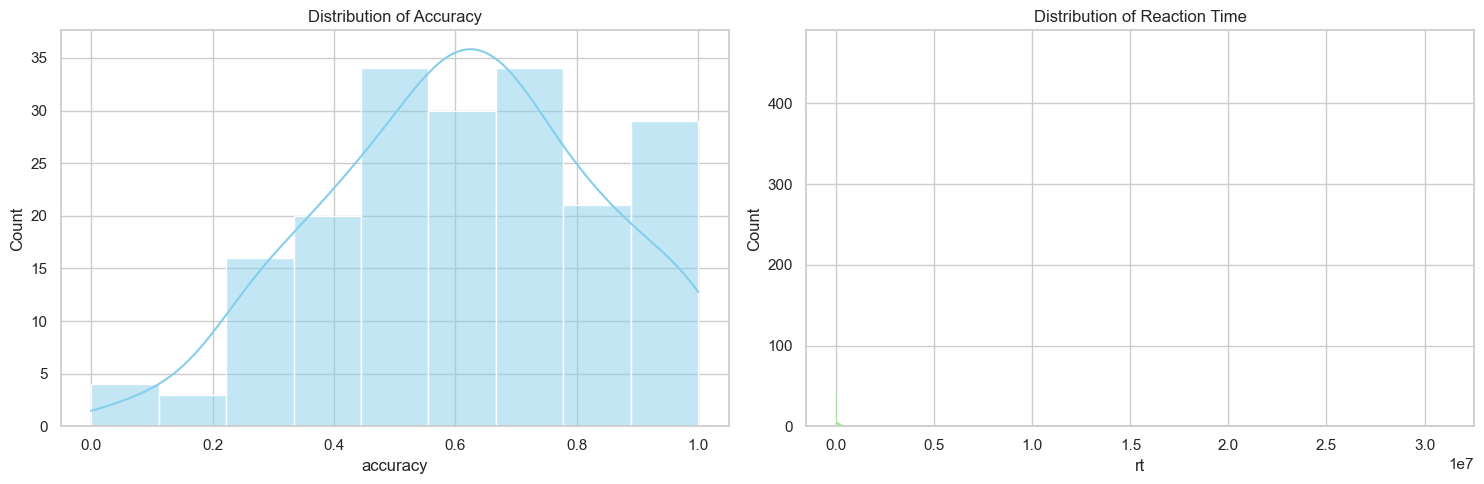

In [25]:

# Set up the plot style
sns.set(style="whitegrid")

# Create histograms for numeric variables
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plotting the distribution of accuracy
sns.histplot(merged_df['accuracy'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Accuracy')

# Plotting the distribution of reaction time
sns.histplot(merged_df['rt'].dropna(), kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Reaction Time')

plt.tight_layout()
plt.show()

In [1]:

import sweetviz as sv
import pandas as pd

df = pd.read_csv('cleaned_data.csv')
report = sv.analyze(df)
report.show_html('sweetviz_report.html')



                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [4]:

# Load the cleaned data
file_path = "cleaned_data.csv"  # Update with the actual file path
df = pd.read_csv(file_path)

# Ensure 'response' is a string and remove extra spaces
df["response"] = df["response"].astype(str).str.strip()

# Filter rows where 'response' contains "baseline" or "post survey" (case-insensitive)
survey_data = df[df["response"].str.contains(r"(?i)\b(baseline|reflect)", na=False)]

# Keep only relevant columns
survey_data = survey_data[["random_id", "rt", "phase", "response"]]

# Save the extracted survey responses to a new CSV
output_path = "survey_data.csv"
survey_data.to_csv(output_path, index=False)

print(f"Survey responses saved to {output_path}")


Survey responses saved to survey_data.csv


/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_43327/362666579.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  survey_data = df[df["response"].str.contains(r"(?i)\b(baseline|reflect)", na=False)]


In [2]:


# Load the survey data
survey_file_path = "survey_data.csv"
survey_df = pd.read_csv(survey_file_path)

# Ensure 'response' is treated as a string and remove extra spaces
survey_df["response"] = survey_df["response"].astype(str).str.strip()

# Step 1: Identify Baseline vs. Post-Survey Responses
survey_df["survey_type"] = survey_df["response"].apply(
    lambda x: "baseline" if "baseline" in x.lower() else "reflect"
)

# Step 2: Reshape the Data to Have One Row per Participant
# Pivot so that baseline and post-survey responses are separate columns
df_wide = survey_df.pivot(index="random_id", columns="survey_type", values="response").reset_index()

# Rename columns for clarity
df_wide.columns = ["random_id", "baseline_response", "post_survey_response"]

# Save the structured data
output_path = "data/structured_survey_responses.csv"
df_wide.to_csv(output_path, index=False)

# Show first few rows of the structured data
df_wide.head()


OSError: Cannot save file into a non-existent directory: 'data'

/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_58481/1200895639.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="condition", y="accuracy", data=df, ax=axes[0], palette=palette)
/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_58481/1200895639.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="condition", y="miss_rate", data=df, ax=axes[1], palette=palette)
/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_58481/1200895639.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="condition", y="rt",

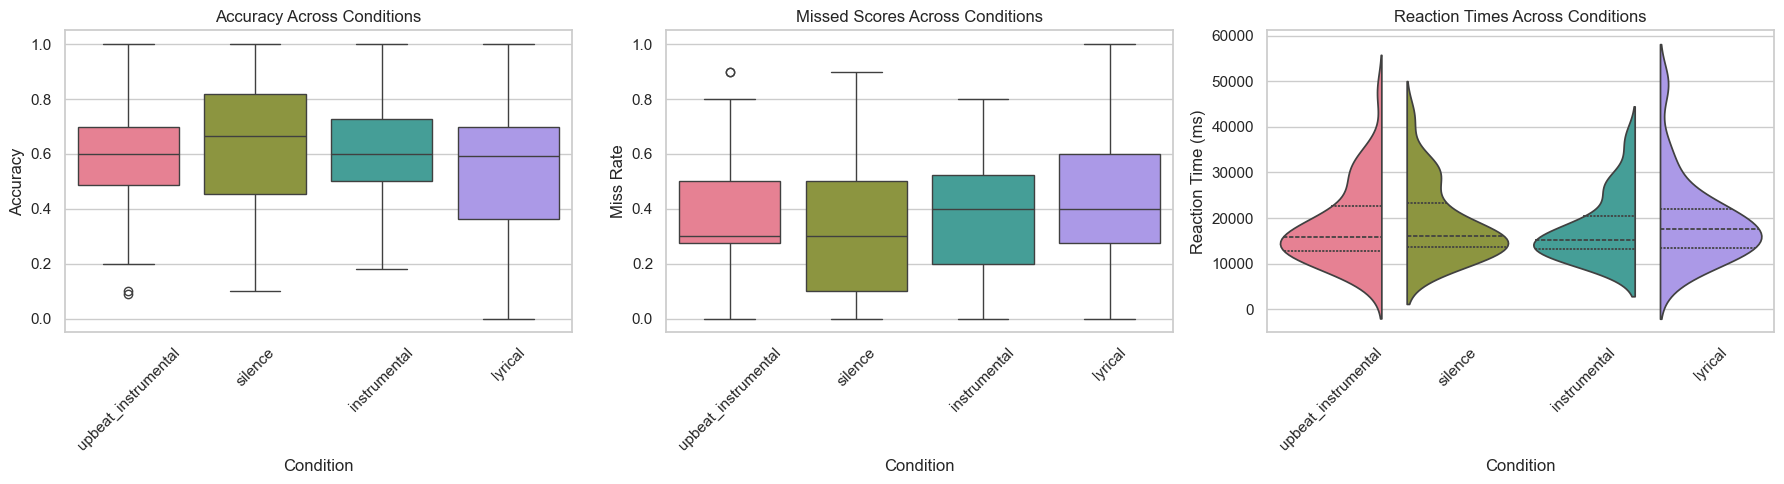

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned data
file_path = "cleaned_data.csv"  # Update with correct path
df = pd.read_csv(file_path)

# Drop NaNs in phase column before filtering
df = df.dropna(subset=["phase"])

# Filter only recall phases
df = df[df["phase"].str.startswith("recall_")]

# Exclude "recall_vocal"
df = df[df["phase"] != "recall_vocal"]

# Extract condition names by removing "recall_" prefix
df["condition"] = df["phase"].str.replace("recall_", "", regex=False)

# Set Seaborn style
sns.set(style="whitegrid")

# Create subplots for Accuracy, Missed Scores, and RT
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define a color palette for the conditions
palette = sns.color_palette("husl", n_colors=len(df["condition"].unique()))

# 1. Accuracy Across Conditions
sns.boxplot(x="condition", y="accuracy", data=df, ax=axes[0], palette=palette)
axes[0].set_title("Accuracy Across Conditions")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Accuracy")

# 2. Missed Scores Across Conditions
sns.boxplot(x="condition", y="miss_rate", data=df, ax=axes[1], palette=palette)
axes[1].set_title("Missed Scores Across Conditions")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Miss Rate")

# 3. Reaction Times Across Conditions
sns.violinplot(x="condition", y="rt", data=df, ax=axes[2], palette=palette, inner="quartile", split=True)
axes[2].set_title("Reaction Times Across Conditions")
axes[2].set_xlabel("Condition")
axes[2].set_ylabel("Reaction Time (ms)")

# Rotate x-axis labels for readability
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Show plots
plt.tight_layout()
plt.show()

/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_1761/2759167378.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="condition", y="accuracy", data=df, ax=axes[0], inner=None, linewidth=1.2, palette=palette)
/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_1761/2759167378.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="condition", y="miss_rate", data=df, ax=axes[1], inner=None, linewidth=1.2, palette=palette)
/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_1761/2759167378.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabe

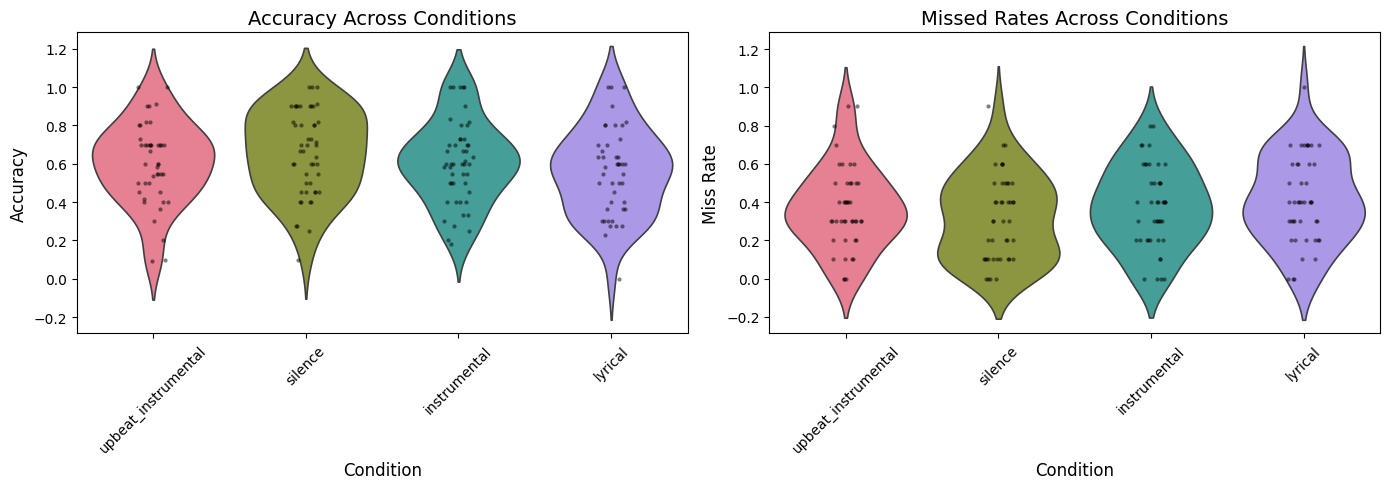

0.3710227272727273


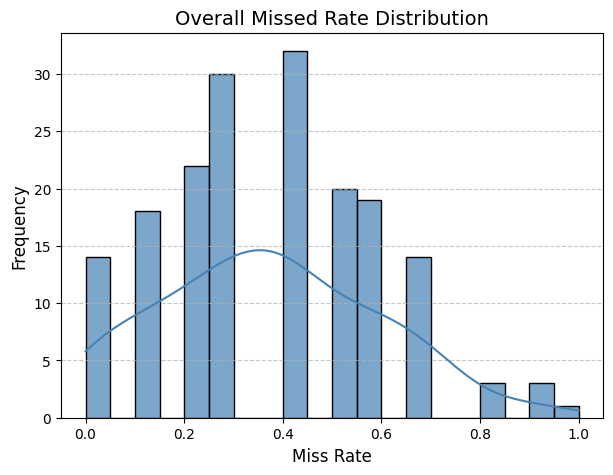

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned data
file_path = "cleaned_data.csv"  # Update with correct path
df = pd.read_csv(file_path)

# Drop NaNs in phase column before filtering
df = df.dropna(subset=["phase"])

# Filter only recall phases and exclude "recall_vocal"
df = df[df["phase"].str.startswith("recall_")]
df = df[df["phase"] != "recall_vocal"]

# Extract condition names by removing "recall_" prefix
df["condition"] = df["phase"].str.replace("recall_", "", regex=False)

# Create subplots for Accuracy and Missed Rates per Condition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define a color palette for the conditions
palette = sns.color_palette("husl", n_colors=len(df["condition"].unique()))

# 1. Accuracy Across Conditions
sns.violinplot(x="condition", y="accuracy", data=df, ax=axes[0], inner=None, linewidth=1.2, palette=palette)
sns.stripplot(x="condition", y="accuracy", data=df, ax=axes[0], color="black", size=3, jitter=True, alpha=0.5)
axes[0].set_title("Accuracy Across Conditions", fontsize=14)
axes[0].set_xlabel("Condition", fontsize=12)
axes[0].set_ylabel("Accuracy", fontsize=12)

# 2. Missed Rates Across Conditions
sns.violinplot(x="condition", y="miss_rate", data=df, ax=axes[1], inner=None, linewidth=1.2, palette=palette)
sns.stripplot(x="condition", y="miss_rate", data=df, ax=axes[1], color="black", size=3, jitter=True, alpha=0.5)
axes[1].set_title("Missed Rates Across Conditions", fontsize=14)
axes[1].set_xlabel("Condition", fontsize=12)
axes[1].set_ylabel("Miss Rate", fontsize=12)

# Rotate x-axis labels for readability
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

mean1 = df["miss_rate"].mean()
print(mean1)
# 3. Overall Missed Rate Distribution
plt.figure(figsize=(7, 5))
sns.histplot(df["miss_rate"], kde=True, bins=20, color="steelblue", edgecolor="black", alpha=0.7)
plt.title("Overall Missed Rate Distribution", fontsize=14)
plt.xlabel("Miss Rate", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

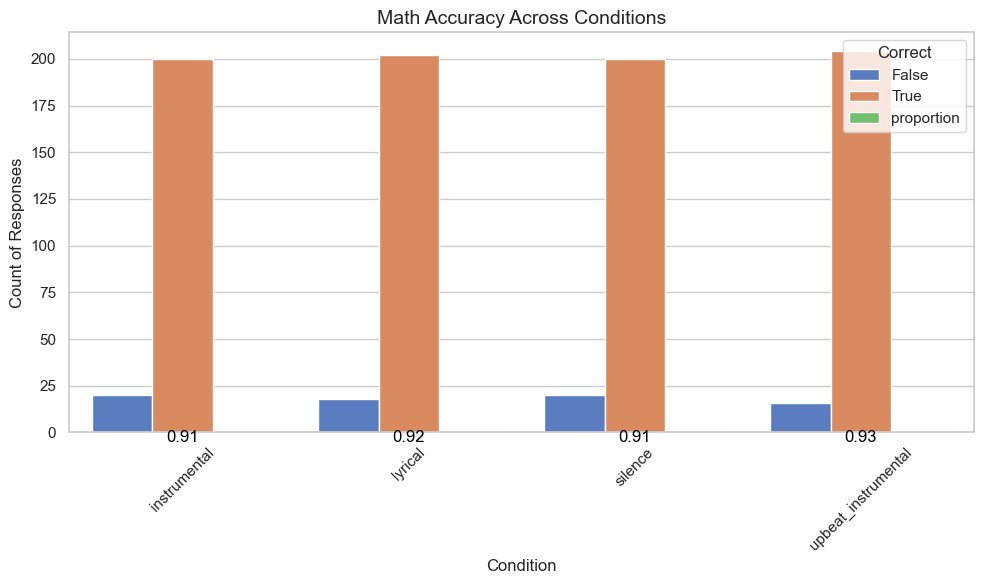

In [14]:

df = pd.read_csv("cleaned_data.csv")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Drop NaN values in 'phase' before filtering
df = df.dropna(subset=["phase"])

# Filter only math distractor trials
math_df = df[df["phase"].str.startswith("math_distractor_")].copy()

# Extract condition names by removing "math_distractor_" prefix
math_df["condition"] = math_df["phase"].str.replace("math_distractor_", "", regex=False)

# Ensure 'correct' column is boolean
math_df["correct"] = math_df["correct"].astype(bool)

# Count correct/incorrect answers per condition
accuracy_counts = math_df.groupby(["condition", "correct"]).size().reset_index(name="count")

# Pivot to ensure all conditions have both True and False
accuracy_pivot = accuracy_counts.pivot_table(index="condition", columns="correct", values="count", fill_value=0)

# Rename columns
accuracy_pivot.columns = ["False", "True"]

# Normalize to get accuracy proportion
accuracy_pivot["proportion"] = accuracy_pivot["True"] / (accuracy_pivot["True"] + accuracy_pivot["False"])

# Convert to long format for seaborn
plot_df = accuracy_pivot.reset_index().melt(id_vars="condition", var_name="Correct", value_name="Count")

# Set seaborn theme
sns.set_theme(style="whitegrid", palette="muted")

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="condition", y="Count", hue="Correct", data=plot_df)

# Add numerical accuracy values under each condition
for i, condition in enumerate(accuracy_pivot.index):
    avg = accuracy_pivot.loc[condition, "proportion"]
    ax.text(i, -5, f"{avg:.2f}", ha="center", fontsize=12, color="black")

# Labels and title
plt.title("Math Accuracy Across Conditions", fontsize=14)
plt.xlabel("Condition", fontsize=12)
plt.ylabel("Count of Responses", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Correct", loc="upper right")
plt.tight_layout()
plt.show()



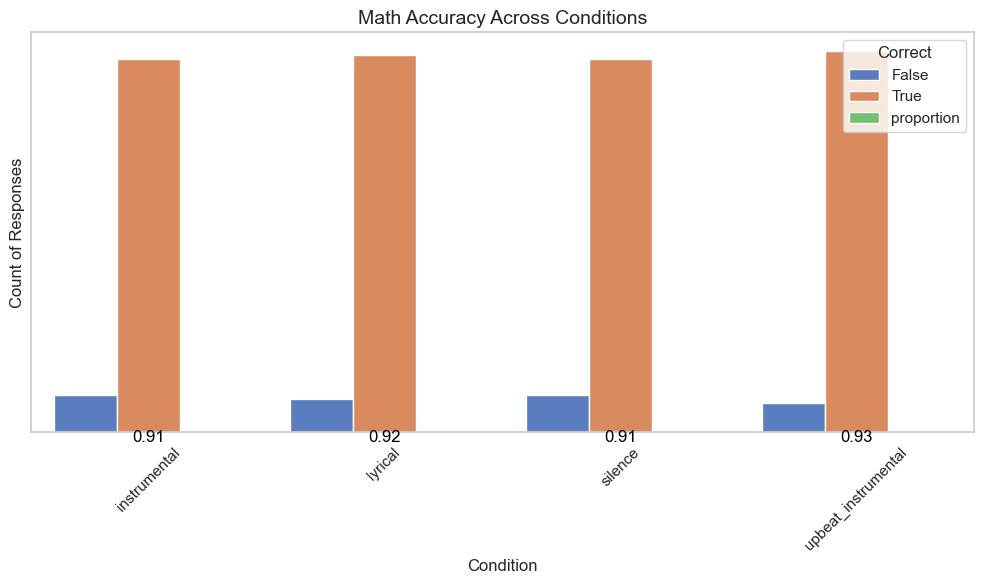

In [15]:
# Set seaborn theme
sns.set_theme(style="whitegrid", palette="muted")

# Create the bar plot without proportion or extra bar
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="condition", y="Count", hue="Correct", data=plot_df)

# Add numerical accuracy values under each condition
for i, condition in enumerate(accuracy_pivot.index):
    avg = accuracy_pivot.loc[condition, "proportion"]
    ax.text(i, -5, f"{avg:.2f}", ha="center", fontsize=12, color="black")

# Labels and title
plt.title("Math Accuracy Across Conditions", fontsize=14)
plt.xlabel("Condition", fontsize=12)
plt.ylabel("Count of Responses", fontsize=12)
plt.xticks(rotation=45)

# Remove the proportion bar and legend if not needed
plt.legend(title="Correct", loc="upper right")

# Remove 'proportion' from the plot if you're referring to axes or labels showing proportions
ax.set_yticklabels([])  # Removes any y-tick labels for proportions (if present)
ax.get_yaxis().set_ticks([])  # Optionally remove the y-axis ticks

plt.tight_layout()
plt.show()


Average Before Motivation: 5.653061224489796
Average After Motivation: 6.489795918367347


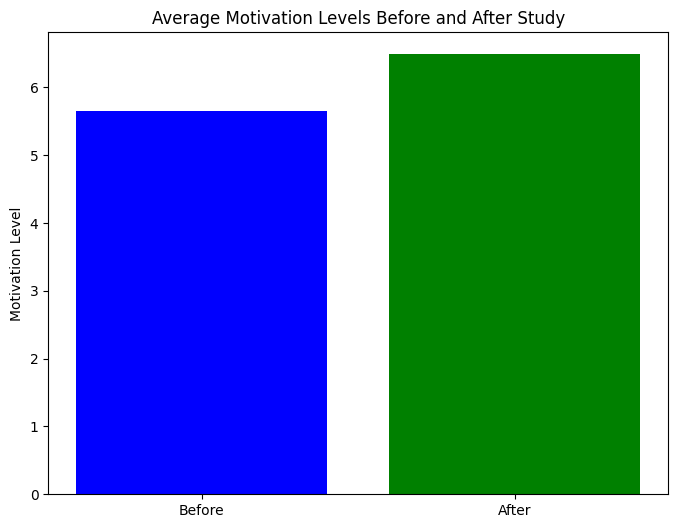

/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_1761/2606266997.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Genre', y='Count', data=genre_df, palette='viridis')


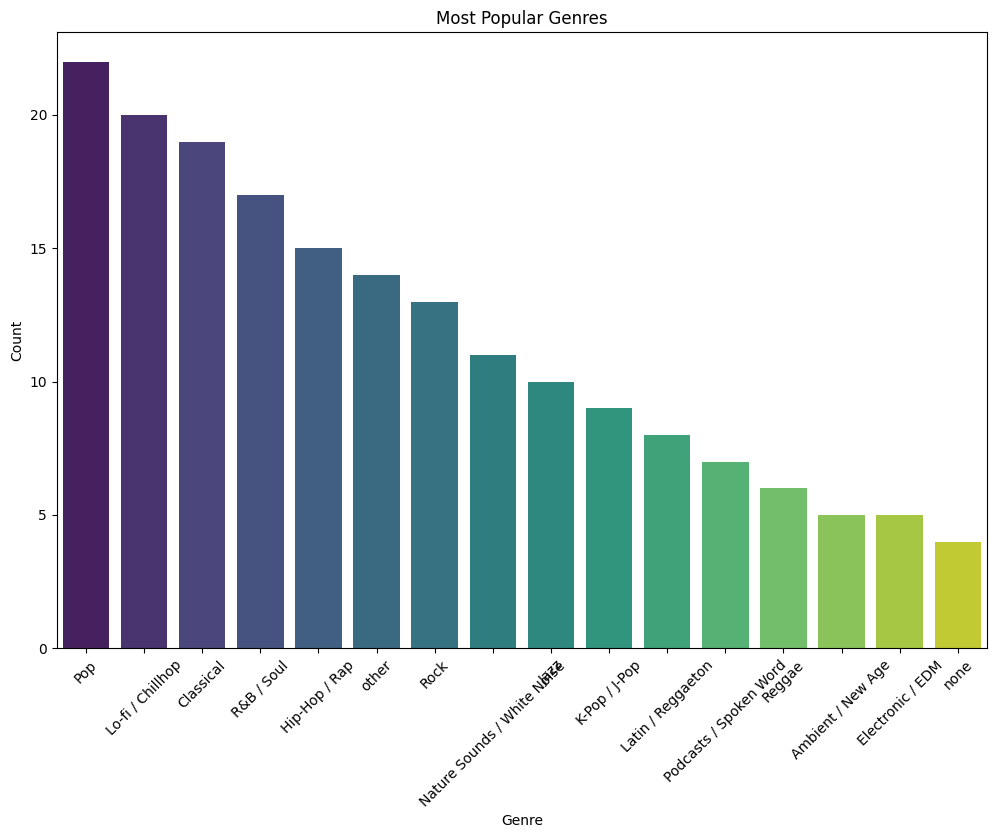

Age Range: (18.0, 40.0, 20.979591836734695)


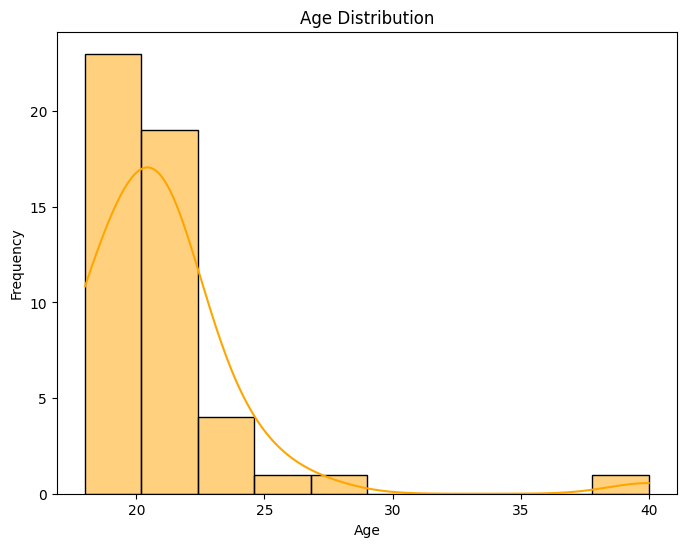

/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_1761/2606266997.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Race', y='Count', data=race_df, palette='magma')


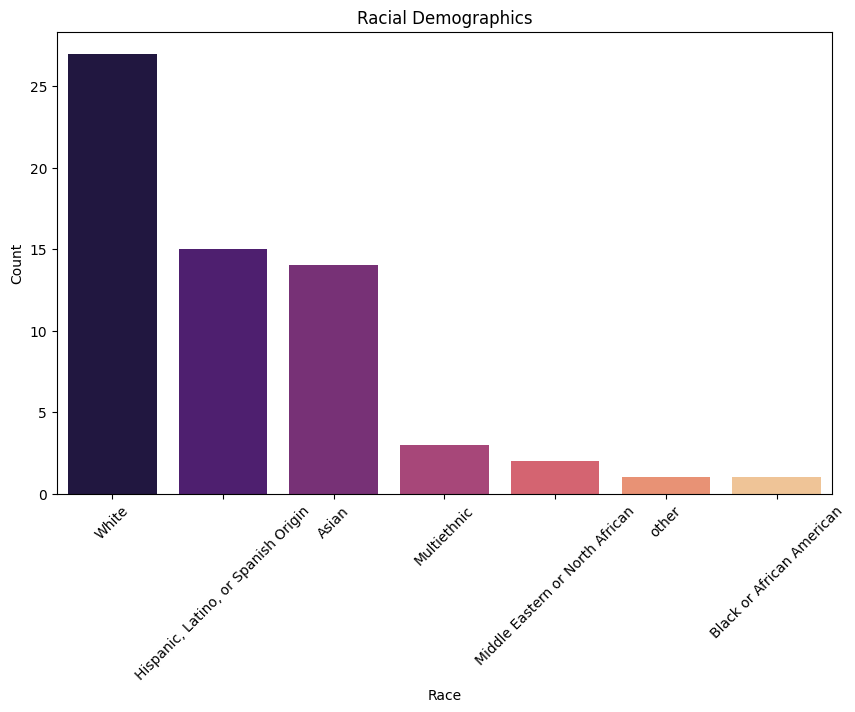

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

# Load the data
data = pd.read_csv('Expanded_Response_Data.csv')

# 1. Before and After Motivation Levels
before_motivation = data['baseline-study-motivation'].mean()
after_motivation = data['reflect-study-motivation'].mean()

print(f"Average Before Motivation: {before_motivation}")
print(f"Average After Motivation: {after_motivation}")

# Plotting motivation levels
plt.figure(figsize=(8, 6))
plt.bar(['Before', 'After'], [before_motivation, after_motivation], color=['blue', 'green'])
plt.title('Average Motivation Levels Before and After Study')
plt.ylabel('Motivation Level')
plt.show()

# 2. Most Popular Genres
# Extract and flatten the list of genres
all_genres = []
for genre_list in data['baseline-music-type']:
    try:
        # Convert string representation of list to actual list
        genres = ast.literal_eval(genre_list)
        all_genres.extend(genres)
    except:
        # Handle cases where the data is not a list (e.g., NaN or other formats)
        pass

# Count the frequency of each genre
genre_counts = Counter(all_genres)

# Convert to DataFrame for easier plotting
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

# Plotting most popular genres
plt.figure(figsize=(12, 8))
sns.barplot(x='Genre', y='Count', data=genre_df, palette='viridis')
plt.title('Most Popular Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 3. Age Range
age_range = (data['baseline-age'].min(), data['baseline-age'].max(), data['baseline-age'].mean())
print(f"Age Range: {age_range}")

# Plotting age distribution
plt.figure(figsize=(8, 6))
sns.histplot(data['baseline-age'], bins=10, kde=True, color='orange')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 4. Racial Demographics
# Extract and flatten the list of races
all_races = []
for race_list in data['baseline-race']:
    try:
        # Convert string representation of list to actual list
        races = ast.literal_eval(race_list)
        all_races.extend(races)
    except:
        # Handle cases where the data is not a list (e.g., NaN or other formats)
        pass

# Count the frequency of each race
race_counts = Counter(all_races)

# Convert to DataFrame for easier plotting
race_df = pd.DataFrame(race_counts.items(), columns=['Race', 'Count']).sort_values(by='Count', ascending=False)

# Plotting racial demographics
plt.figure(figsize=(10, 6))
sns.barplot(x='Race', y='Count', data=race_df, palette='magma')
plt.title('Racial Demographics')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [9]:
import pandas as pd
import pingouin as pg

# Load the cleaned dataset
df = pd.read_csv("cleaned_data.csv")

# Drop NaN values in 'phase' before filtering
df = df.dropna(subset=["phase"])

# Filter only math distractor trials
math_df = df[df["phase"].str.startswith("math_distractor_")].copy()

# Extract condition names by removing "math_distractor_" prefix
math_df["condition"] = math_df["phase"].str.replace("math_distractor_", "", regex=False)

# Ensure 'correct' column is boolean
math_df["correct"] = math_df["correct"].astype(bool)

# Compute accuracy per participant per condition
accuracy_df = math_df.groupby(["random_id", "condition"])["correct"].mean().reset_index()

# Perform one-way repeated measures ANOVA
anova_results = pg.rm_anova(dv="correct", within="condition", subject="random_id", data=accuracy_df, detailed=True)

# Print ANOVA table
print(anova_results)

# Perform post-hoc pairwise comparisons (if needed)
posthoc_results = pg.pairwise_ttests(dv="correct", within="condition", subject="random_id", data=accuracy_df, padjust="bonferroni")

# Print post-hoc results
print(posthoc_results)


      Source    SS   DF        MS         F     p-unc       ng2       eps
0  condition  0.01    3  0.003333  0.248555  0.862242  0.002945  0.911194
1      Error  1.73  129  0.013411       NaN       NaN       NaN       NaN
    Contrast             A                    B  Paired  Parametric  \
0  condition  instrumental              lyrical    True        True   
1  condition  instrumental              silence    True        True   
2  condition  instrumental  upbeat_instrumental    True        True   
3  condition       lyrical              silence    True        True   
4  condition       lyrical  upbeat_instrumental    True        True   
5  condition       silence  upbeat_instrumental    True        True   

              T   dof alternative     p-unc  p-corr    p-adjust   BF10  \
0 -3.742528e-01  43.0   two-sided  0.710056     1.0  bonferroni  0.174   
1  9.146120e-17  43.0   two-sided  1.000000     1.0  bonferroni  0.163   
2 -7.521898e-01  43.0   two-sided  0.456035     1.0  bonfe

/opt/anaconda3/lib/python3.11/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


In [17]:
import pandas as pd
from scipy.stats import ttest_rel

# Load the data
data = pd.read_csv('Expanded_Response_Data.csv')

# Group by 'random_id' and aggregate pre and post motivation values
grouped_data = data.groupby('random_id').agg({
    'baseline-study-motivation': 'mean',  # Aggregate pre motivation
    'reflect-study-motivation': 'mean'    # Aggregate post motivation
}).reset_index()

# Rename columns for clarity
grouped_data.columns = ['random_id', 'Pre', 'Post']

# Check the grouped data
print("Grouped data (aggregated by individual):")
print(grouped_data.head())

# Impute missing values with the mean of the respective column
grouped_data['Pre'].fillna(grouped_data['Pre'].mean(), inplace=True)
grouped_data['Post'].fillna(grouped_data['Post'].mean(), inplace=True)

# Perform the paired t-test
t_stat, p_value = ttest_rel(grouped_data['Pre'], grouped_data['Post'])

# Output the results
print(f"Paired t-test results:")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpret the results
if p_value < 0.05:
    print("There is a significant difference between pre and post motivation levels.")
else:
    print("There is no significant difference between pre and post motivation levels.")

Grouped data (aggregated by individual):
     random_id  Pre  Post
0  p0do0zvof09  7.0   5.0
1  p0j4gk7z0tg  7.0   7.0
2  p0vqdg59kpg  5.0   8.0
3  p213h3m86k1  7.0   7.0
4  p22eac6c2ul  8.0   9.0
Paired t-test results:
T-statistic: -2.2181073012818833
P-value: 0.03131302267029909
There is a significant difference between pre and post motivation levels.


/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_52154/127149108.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grouped_data['Pre'].fillna(grouped_data['Pre'].mean(), inplace=True)
/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_52154/127149108.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

In [5]:
import pandas as pd
from scipy.stats import ttest_rel

# Load the data
data = pd.read_csv('Expanded_Response_Data.csv')

# Group by 'random_id' and aggregate pre and post motivation values
grouped_data = data.groupby('random_id').agg({
    'reflect-study-motivation': 'mean',  # Aggregate pre motivation
    'reflect-study-mood': 'mean'    # Aggregate post motivation
}).reset_index()

# Rename columns for clarity
grouped_data.columns = ['random_id', 'Pre', 'Post']

# Check the grouped data
print("Grouped data (aggregated by individual):")
print(grouped_data.head())

# Impute missing values with the mean of the respective column
grouped_data['Pre'].fillna(grouped_data['Pre'].mean(), inplace=True)
grouped_data['Post'].fillna(grouped_data['Post'].mean(), inplace=True)

# Perform the paired t-test
t_stat, p_value = ttest_rel(grouped_data['Pre'], grouped_data['Post'])

# Output the results
print(f"Paired t-test results:")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpret the results
if p_value < 0.05:
    print("There is a significant difference between post motivation levels and mood. ")
else:
    print("There is no significant difference between post motivation levels and mood")

Grouped data (aggregated by individual):
     random_id  Pre  Post
0  p0do0zvof09  5.0   7.0
1  p0j4gk7z0tg  7.0   6.0
2  p0vqdg59kpg  8.0   8.0
3  p213h3m86k1  7.0   7.0
4  p22eac6c2ul  9.0   6.0
Paired t-test results:
T-statistic: -4.877323560046641
P-value: 1.222697425125741e-05
There is a significant difference between post motivation levels and mood. 


/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_1761/1264243590.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grouped_data['Pre'].fillna(grouped_data['Pre'].mean(), inplace=True)
/var/folders/jq/kgdcv4rj3q97yh8qv3zdwry40000gn/T/ipykernel_1761/1264243590.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are